`What is a custom dataset?`

I have got my own datasets, can I build a model with PyTorch to predict on it - `YES`

A custom dataset is a collection of data relating to a specific problem you're working on.

<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pytorch-domain-libraries.png" alt="A description of the image" width="900" height="500">

PyTorch includes many existing functions to load in various custom datasets in the `TorchVision, TorchText, TorchAudio and TorchRec` domain libraries.

But sometimes these existing functions may not be enough.

In that case, we can always subclass torch.utils.data.Dataset and customize it to our liking.


`What we're going to cover`

We're going to be applying the PyTorch Workflow we covered in notebook 01 and notebook 02 to a computer vision problem.

But instead of using an in-built PyTorch dataset, we're going to be using our own dataset of pizza, steak and sushi images.

The goal will be to load these images and then build a model to train and predict on them.
<img src="https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pytorch-food-vision-layout.png" alt="A description of the image" width="900" height="500">


In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import requests
import zipfile
import random
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import os

torch.__version__

'2.10.0+cu128'

In [3]:
# setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# 1. Get data

Our dataset is a subset of the Food101 dataset.

Food101 starts 101 different classes of food and 1000 images per class (750 train, 250 test)

Our dataset starts with 3 classes of food and only 10% of the images (~75 train, 25 testin)

Why do this 

When starting our ML projects, it's important to try things on a small scale and then increase the scale when necessary.

the whole point us to speed up how fast you can experiment


In [4]:
# Setup path to data folder
data_path = Path("../datasets/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...") 
        zip_ref.extractall(image_path)

Did not find ../datasets/pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


# 2. Becoming one with data(data preparation and data exploration)

In [5]:
def walk_through_dir(dir_path):
    """ Walks through dir_path returning its content """
    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'")

In [6]:
walk_through_dir(image_path)

There are 2 directories and 0 images in '../datasets/pizza_steak_sushi'
There are 3 directories and 0 images in '../datasets/pizza_steak_sushi/train'
There are 0 directories and 75 images in '../datasets/pizza_steak_sushi/train/steak'
There are 0 directories and 78 images in '../datasets/pizza_steak_sushi/train/pizza'
There are 0 directories and 72 images in '../datasets/pizza_steak_sushi/train/sushi'
There are 3 directories and 0 images in '../datasets/pizza_steak_sushi/test'
There are 0 directories and 19 images in '../datasets/pizza_steak_sushi/test/steak'
There are 0 directories and 25 images in '../datasets/pizza_steak_sushi/test/pizza'
There are 0 directories and 31 images in '../datasets/pizza_steak_sushi/test/sushi'


In [7]:
# setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('../datasets/pizza_steak_sushi/train'),
 PosixPath('../datasets/pizza_steak_sushi/test'))

# visualizing and image

Let's write some code to:
1. Get all of the image paths
2. Pick a random image path using Python's random choice()
3. Get the image class name using `path.lib.Path.parent.stem`
4. Since we are working with image, let's open the image with Python's PIL
5. We will them show the image and print metadata

../datasets/pizza_steak_sushi/train/steak/1736968.jpg
steak
Random image path: ../datasets/pizza_steak_sushi/train/steak/1736968.jpg
Image class: steak
Image height: 512
Image width: 512


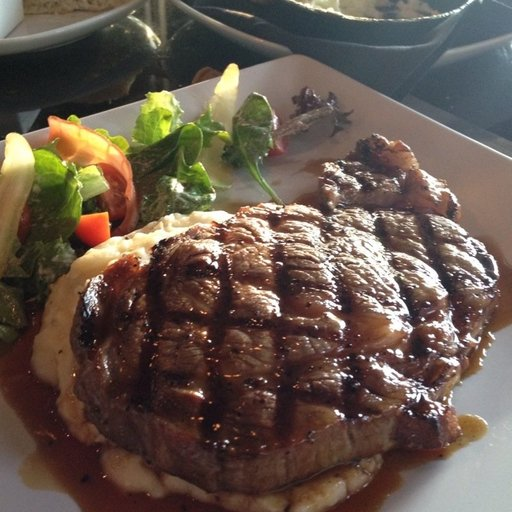

In [8]:
# set seed
random.seed(42)

# 1. Get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))

# 2. Pick a random image path
random_image_path = random.choice(image_path_list)
print(random_image_path)

# 3. Ge image class from path name(the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem
"""
parent = \datasets\pizza_steak_sushi\test
stem = sushi\
"""
print(image_class)

# 4. Open image
img = Image.open(random_image_path)

# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

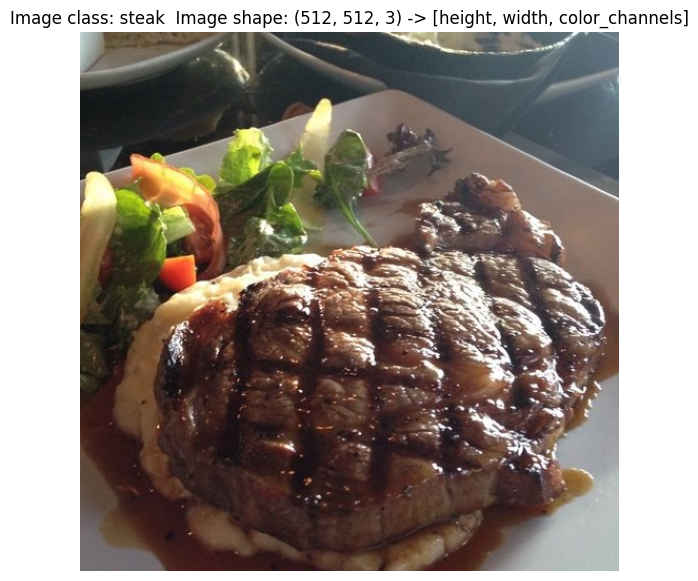

In [9]:
# Turn the image into an array
img_as_array = np.asanyarray(img)

# Plot the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class}  Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False)

In [10]:
img_as_array

array([[[200, 216, 213],
        [192, 208, 205],
        [187, 201, 201],
        ...,
        [106, 124, 136],
        [105, 123, 135],
        [103, 121, 133]],

       [[197, 213, 210],
        [192, 208, 205],
        [187, 201, 201],
        ...,
        [106, 124, 136],
        [103, 121, 133],
        [100, 118, 130]],

       [[197, 213, 210],
        [195, 211, 208],
        [189, 205, 204],
        ...,
        [102, 120, 132],
        [107, 125, 137],
        [110, 128, 140]],

       ...,

       [[117, 111, 113],
        [115, 109, 111],
        [115, 109, 111],
        ...,
        [182, 191, 188],
        [182, 191, 188],
        [182, 191, 188]],

       [[116, 110, 112],
        [115, 109, 111],
        [116, 110, 112],
        ...,
        [180, 189, 186],
        [180, 189, 186],
        [181, 190, 187]],

       [[115, 109, 111],
        [115, 109, 111],
        [117, 111, 113],
        ...,
        [185, 194, 191],
        [186, 195, 192],
        [187, 196, 193]]

# 3. Transforming data

Before we can use our image data with PyTorch:
1. Turn your targer data into tensors (in our case, numerical representation of our images)
2. Turn it into a `torch.utils.data.Dataset` and subsequently a `torch.utils.data.DataLoader`, we will call these `Dataset` and `DataLoader` 

In [11]:
# Write a transform for image
data_transform = transforms.Compose([
    # Resize our images to 64x64
    transforms.Resize(size=(64, 64)),

    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5),

    # Trun the image into a torc.Tensor
    transforms.ToTensor()
])

In [12]:
data_transform(img)

tensor([[[0.7098, 0.6353, 0.5176,  ..., 0.3922, 0.4157, 0.4235],
         [0.6941, 0.6196, 0.5176,  ..., 0.3686, 0.3804, 0.3961],
         [0.6627, 0.5843, 0.4902,  ..., 0.3686, 0.3725, 0.3804],
         ...,
         [0.4510, 0.4510, 0.4471,  ..., 0.7176, 0.7176, 0.7176],
         [0.4549, 0.4549, 0.4510,  ..., 0.7176, 0.7176, 0.7176],
         [0.4549, 0.4549, 0.4510,  ..., 0.7176, 0.7176, 0.7176]],

        [[0.7647, 0.6745, 0.5098,  ..., 0.4667, 0.4902, 0.4941],
         [0.7529, 0.6431, 0.5020,  ..., 0.4471, 0.4510, 0.4667],
         [0.7176, 0.6000, 0.4706,  ..., 0.4392, 0.4431, 0.4510],
         ...,
         [0.4275, 0.4275, 0.4235,  ..., 0.7529, 0.7529, 0.7529],
         [0.4314, 0.4314, 0.4275,  ..., 0.7529, 0.7529, 0.7529],
         [0.4314, 0.4314, 0.4275,  ..., 0.7529, 0.7529, 0.7529]],

        [[0.7608, 0.6549, 0.4588,  ..., 0.5098, 0.5373, 0.5412],
         [0.7373, 0.6196, 0.4431,  ..., 0.4902, 0.4980, 0.5137],
         [0.7020, 0.5725, 0.4196,  ..., 0.4902, 0.4980, 0.

In [13]:

"""
    Plots a series of random images from image_paths.

    Will open n image paths from image_paths, transform them
    with transform and plot them side by side.

    Args:
        image_paths (list): List of target image paths. 
        transform (PyTorch Transforms): Transforms to apply to images.
        n (int, optional): Number of images to plot. Defaults to 3.
        seed (int, optional): Random seed for the random generator. Defaults to 42.
"""
def plot_transformed_images(image_paths, transform, n=3, seed=42):
    if seed:
        random.seed(seed)

    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows=1, ncols=2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original\nSize: {f.size}")
            ax[0].axis(False)
            
            # Transform and plot target image
            transformed_image = transform(f).permute(1, 2, 0) # note we will need to change shape for matplotlib( Color_channel, Heigth, width) -> (H, W, C)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
            ax[1].axis("off")


            fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)


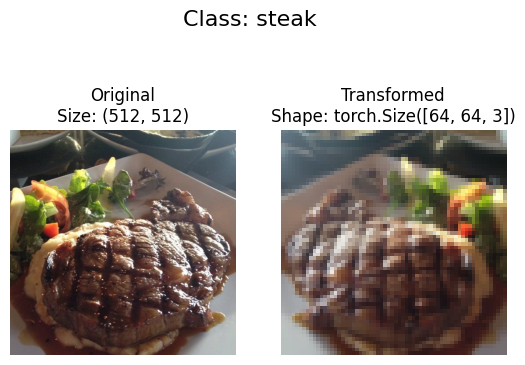

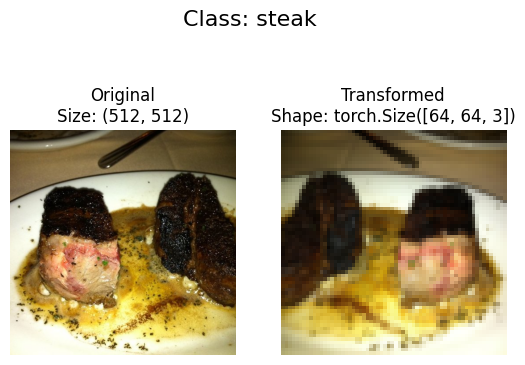

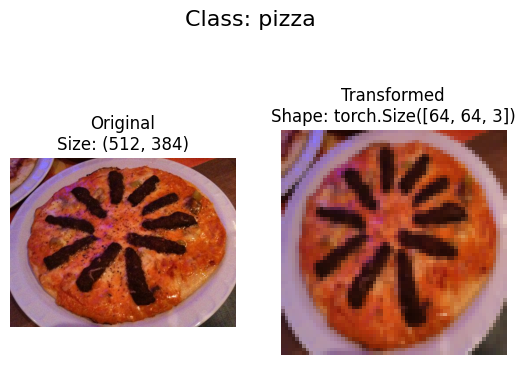

In [14]:
plot_transformed_images(image_paths= image_path_list, transform=data_transform, n=3, seed=42)

In [ ]:
21:00
print("sfs")

SyntaxError: illegal target for annotation (1603520527.py, line 1)